## Setup

In [ ]:
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
BASE_DIR = os.path.join(PROJECT_ROOT, "data")

MULTI_NAME = "potiN2tupiN1"
SINGLE_NAME = "infer_vllm_778989"

MULTI_PATH = os.path.join(BASE_DIR, MULTI_NAME)
SINGLE_PATH = os.path.join(BASE_DIR, SINGLE_NAME)

print("MULTI_PATH:", MULTI_PATH)
print("SINGLE_PATH:", SINGLE_PATH)

MULTI_PATH: c:\Users\rafe_\Documents\Programming\comp-sys-perf-analysis\data\potiN2tupiN1
SINGLE_PATH: c:\Users\rafe_\Documents\Programming\comp-sys-perf-analysis\data\infer_vllm_778989


In [ ]:
experiment_folders = []

# multi-experiment group
if os.path.exists(MULTI_PATH):
    experiment_folders += [
        entry.path for entry in os.scandir(MULTI_PATH) if entry.is_dir()
    ]

# single experiment (already a full experiment folder)
if os.path.exists(SINGLE_PATH):
    experiment_folders.append(SINGLE_PATH)

print("Total experiments:", len(experiment_folders))

Total experiments: 7


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def find_telemetry_files(experiment_path):
    telemetry_files = []

    for root, _, files in os.walk(experiment_path):
        if 'telemetry.csv' in files:
            telemetry_files.append(os.path.join(root, 'telemetry.csv'))

    return telemetry_files

def plot_gpu_utilization_for_experiment(experiment_path):
    experiment_name = os.path.basename(experiment_path)

    telemetry_files = find_telemetry_files(experiment_path)

    if not telemetry_files:
        print(f"No telemetry found for {experiment_name}")
        return

    plt.figure(figsize=(15, 6))

    for file_path in telemetry_files:
        try:
            df = pd.read_csv(file_path)

            # Clean column names (IMPORTANT)
            df.columns = [c.strip() for c in df.columns]

            if 'timestamp' not in df.columns or 'utilization.gpu [%]' not in df.columns:
                continue

            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp')

            # Label by node (folder name: poti1, poti5, tupi6, etc.)
            node_name = os.path.basename(os.path.dirname(file_path))

            plt.plot(
                df['timestamp'],
                df['utilization.gpu [%]'],
                label=node_name
            )

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    plt.title(f'GPU Utilization - {experiment_name}')
    plt.xlabel('Time')
    plt.ylabel('GPU Utilization (%)')
    plt.legend(title='Node')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

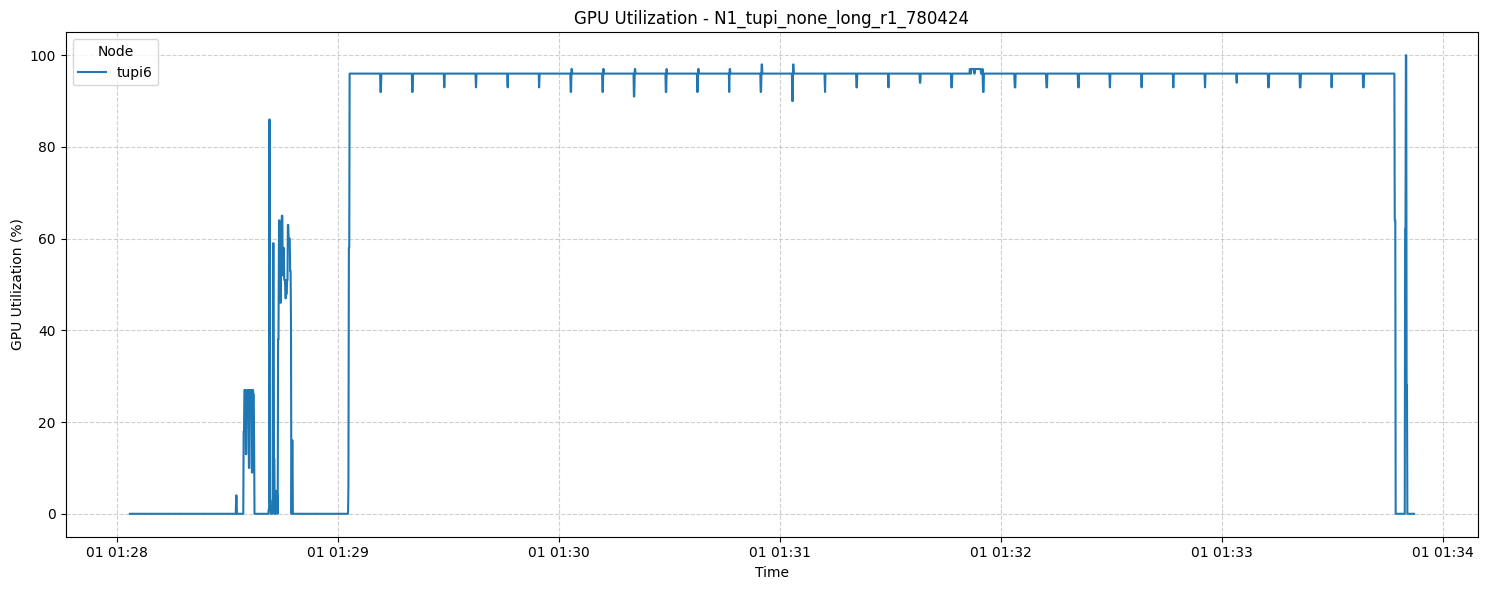

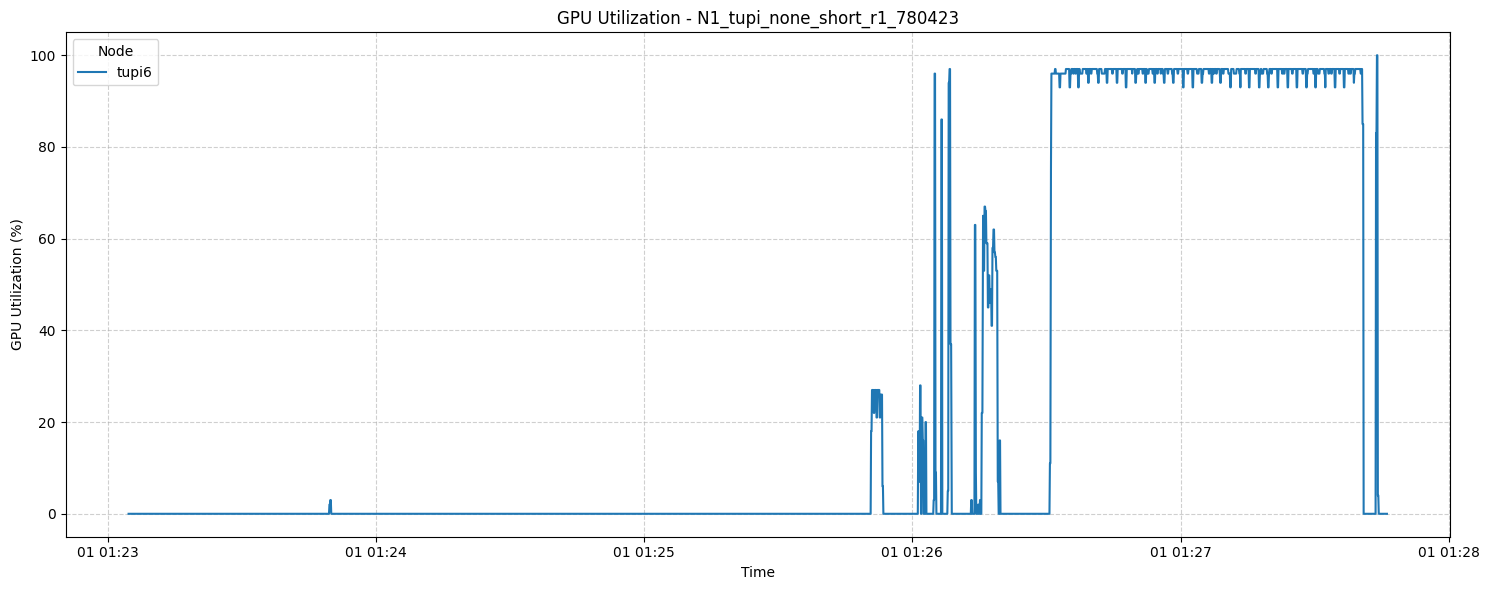

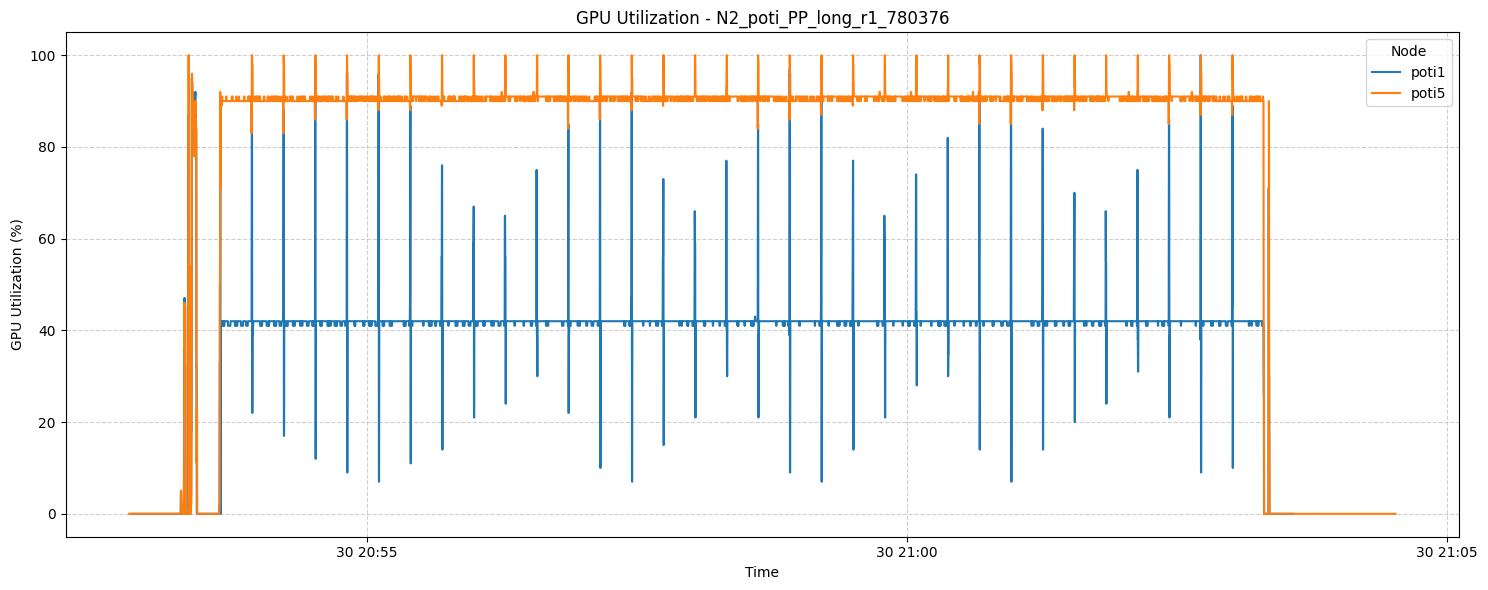

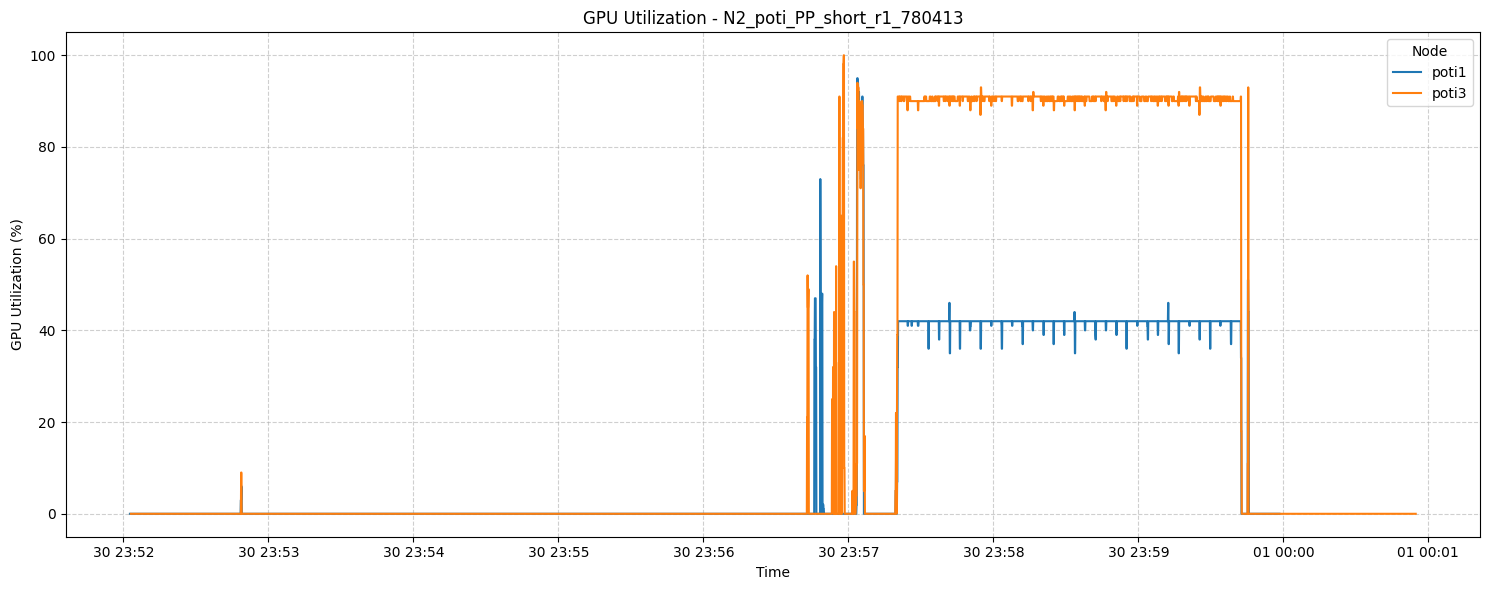

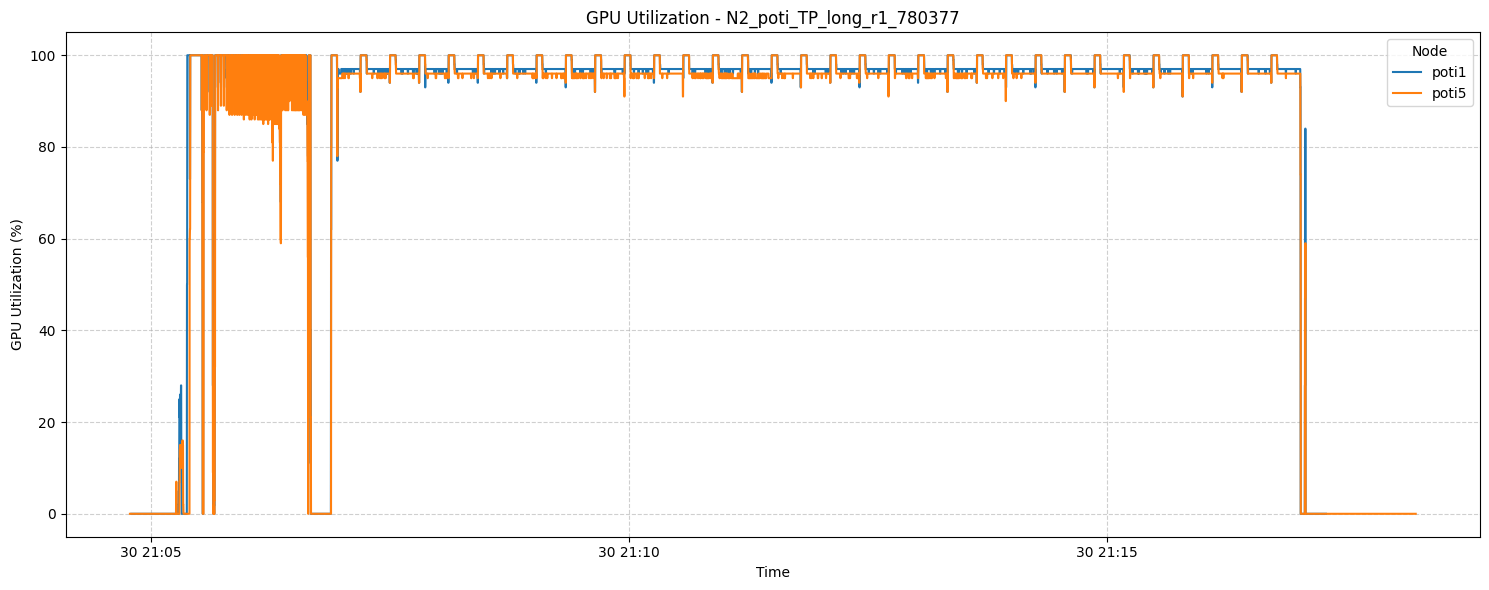

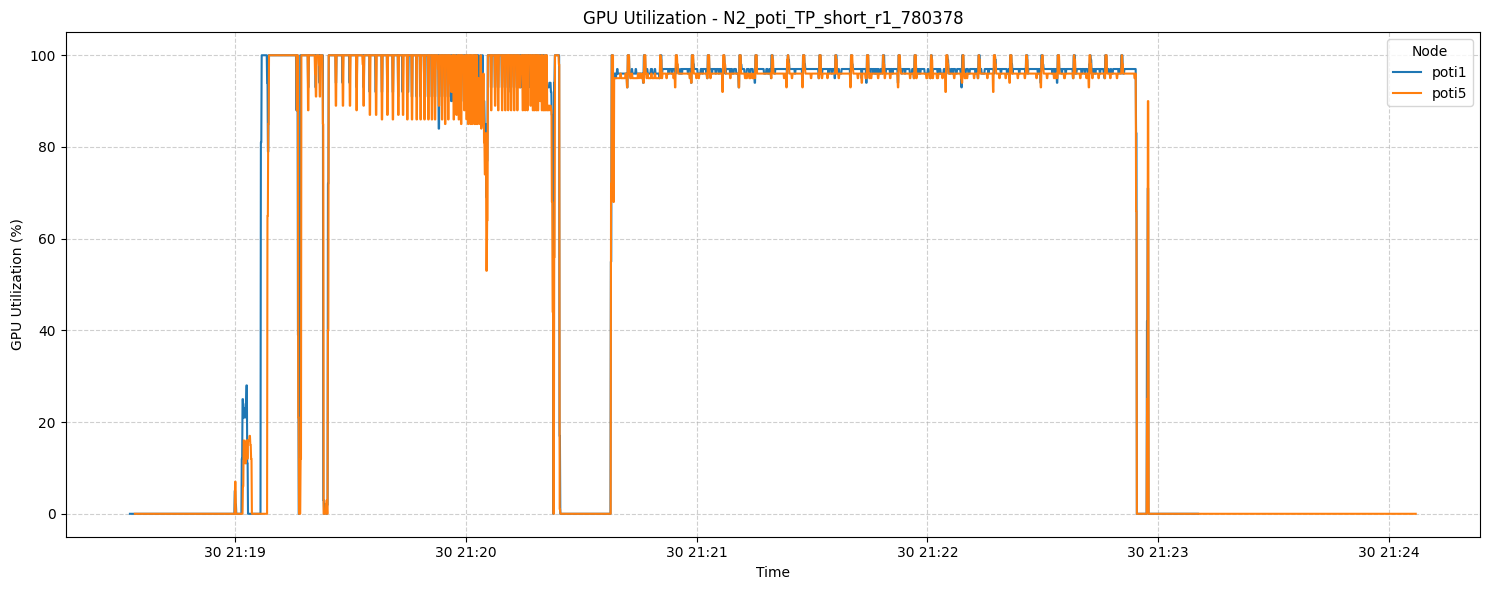

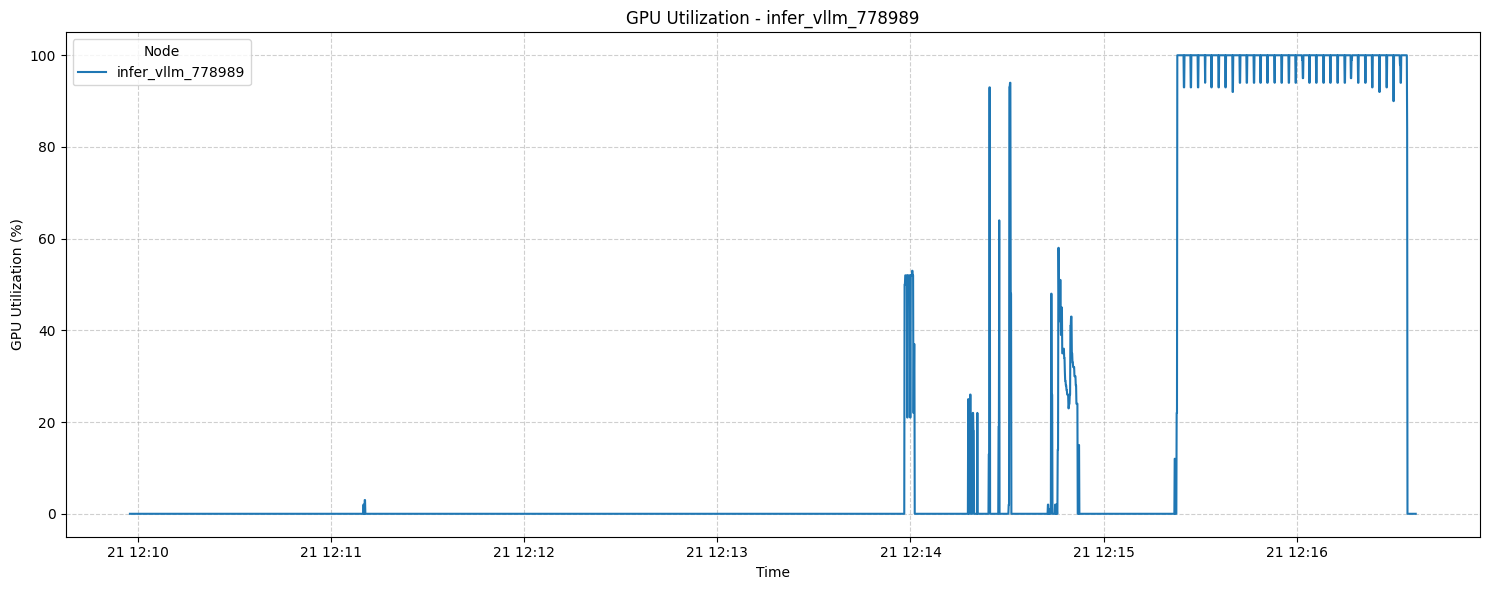

In [ ]:
for exp_path in experiment_folders:
    plot_gpu_utilization_for_experiment(exp_path)